In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mysql.connector

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "#Aks123bsdk",
                             database = "ecommerce_data")
cur = db.cursor()

In [9]:
###List all unique cities where customers are located.
cur.execute("SELECT DISTINCT customer_city FROM customers")

data = cur.fetchall()

In [10]:
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

In [11]:
## 2. Count the number of orders placed in 2017.

cur.execute("SELECT count(order_id) FROM orders where year(order_purchase_timestamp) = 2017")
total_orders = cur.fetchall()
print(total_orders[0][0])

45101


In [12]:
##3. Find the total sales per category.
query = """SELECT products.product_category category, 
round(SUM(payments.payment_value), 2) sales FROM products JOIN order_items
ON products.product_id = order_items.product_id 
JOIN payments ON order_items.order_id = payments.order_id 
GROUP BY category"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "Sales"])
df

,Category,Sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


In [13]:
query = """ SELECT (SUM(CASE 
                         WHEN payment_installments > 1 THEN 1
                         ELSE 0
                       END)
                       )/COUNT(*)*100
            FROM payments
        """
cur.execute(query)
data =cur.fetchall()
print("The total percentage of installement payment is ", data[0][0])

The total percentage of installement payment is  49.4176


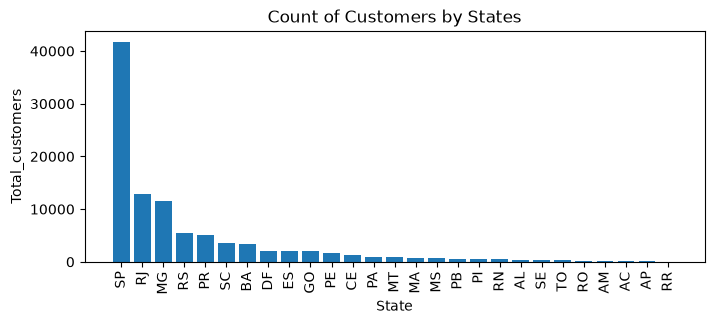

In [14]:
#5. Count the number of customers from each state. 

# ##On the basis of geolocation data
# query = """SELECT geolocation_state, COUNT(*) FROM geolocation GROUP BY geolocation_state
#         """
# cur.execute(query)
# data = cur.fetchall()
# df = pd.DataFrame(data, columns = ["State", "Total_customers"])
# df = df.sort_values(by = "Total_customers", ascending= False)
# plt.figure(figsize = (8,3))
# plt.bar(df["State"], df["Total_customers"])
# plt.xticks(rotation = 90)
# plt.xlabel("State")
# plt.ylabel("Total_customers")
# plt.title("Count of Customers by States")
# plt.show()


####################################################################################

#on the basis of customers data
query = """SELECT customer_state, COUNT(customer_id) FROM customers GROUP BY customer_state
        """
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["State", "Total_customers"])
df = df.sort_values(by = "Total_customers", ascending= False)
plt.figure(figsize = (8,3))
plt.bar(df["State"], df["Total_customers"])
plt.xticks(rotation = 90)
plt.xlabel("State")
plt.ylabel("Total_customers")
plt.title("Count of Customers by States")
plt.show()

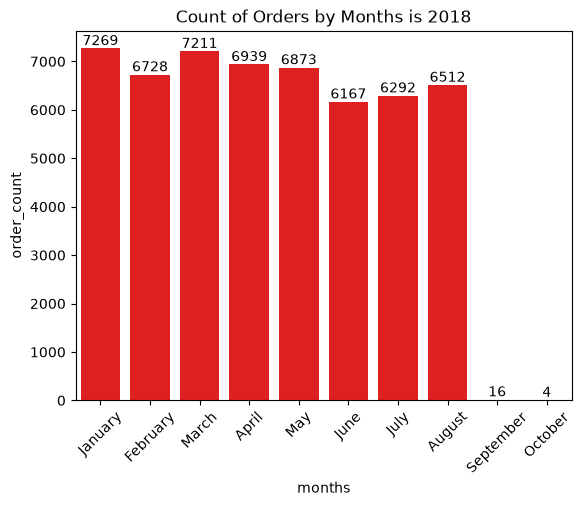

In [15]:
##1. Calculate the number of orders per month in 2018.

query = """
        SELECT MONTHNAME(order_purchase_timestamp), 
        COUNT(order_id) FROM orders 
        WHERE YEAR(order_purchase_timestamp) = 2018
        GROUP BY MONTHNAME(order_purchase_timestamp)
        """
cur.execute(query)
data  = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October"]

ax = sns.barplot(x = df["months"], y = df["order_count"], data = df, order = o, color = "red")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months is 2018")
plt.show()

In [16]:
##2. Find the average number of products per order, grouped by customer city.

query = """
SELECT
    c.customer_city,
    AVG(oi.product_count) AS avg_products_per_order
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN (
    SELECT
        order_id,
        COUNT(product_id) AS product_count
    FROM order_items
    GROUP BY order_id
) oi
    ON o.order_id = oi.order_id
GROUP BY c.customer_city;
"""
cur.execute(query)
data = cur.fetchall()
data

[('anapolis', Decimal('1.1339')),
 ('sao paulo', Decimal('1.1562')),
 ('brasilia', Decimal('1.1304')),
 ('belo horizonte', Decimal('1.1433')),
 ('lagoa santa', Decimal('1.1186')),
 ('osasco', Decimal('1.1456')),
 ('campo grande', Decimal('1.1429')),
 ('rio de janeiro', Decimal('1.1468')),
 ('sao luis', Decimal('1.1236')),
 ('campos dos goytacazes', Decimal('1.0840')),
 ('sao joaquim de bicas', Decimal('1.2500')),
 ('sao jose dos campos', Decimal('1.1385')),
 ('nova friburgo', Decimal('1.0867')),
 ('porto alegre', Decimal('1.1749')),
 ('paripueira', Decimal('1.0000')),
 ('salvador', Decimal('1.1405')),
 ('itaborai', Decimal('1.0667')),
 ('atibaia', Decimal('1.1656')),
 ('ribeirao preto', Decimal('1.1457')),
 ('carmo da mata', Decimal('1.0000')),
 ('andorinha', Decimal('1.0000')),
 ('alegrete', Decimal('1.1429')),
 ('curitiba', Decimal('1.1596')),
 ('maua', Decimal('1.0846')),
 ('presidente prudente', Decimal('1.1313')),
 ('jundiai', Decimal('1.1714')),
 ('macae', Decimal('1.1477')),
 ('

In [17]:
##2. Find the average number of products per order, grouped by customer city.
query = """
select c.customer_city as customer_city,
Avg(oi.product_count) as avg_product_per_city
from customers c join orders o on c.customer_id = o.customer_id
join ( select
order_id, count(product_id) as product_count from order_items group by order_id
) oi
on o.order_id = oi.order_id
group by c.customer_city order by AVG(oi.product_count) desc;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["customer_city", "avg_product_per_city"])
df.head(10)

,customer_city,avg_product_per_city
0,padre carvalho,7.0000
1,celso ramos,6.5000
2,datas,6.0000
3,candido godoi,6.0000
4,matias olimpio,5.0000
5,cidelandia,4.0000
6,picarra,4.0000
7,curralinho,4.0000
8,teixeira soares,4.0000
9,morro de sao paulo,4.0000


In [18]:
# 3. Calculate the percentage of total revenue contributed by each product category.
query = """
select 
p.product_category as category_of_product,
sum(oi.price) as sum_order_category,
sum(oi.price)/(select sum(price) from order_items)*100 AS revenue_percentage
from order_items oi join products p on oi.product_id = p.product_id
group by p.product_category order by sum_order_category desc;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["product_category", "sum_order_category,", "revenue_percentage"])
df.head(5)

,product_category,"sum_order_category,",revenue_percentage
0,HEALTH BEAUTY,1.258681e+06,9.260700
1,Watches present,1.205006e+06,8.865783
2,bed table bath,1.036989e+06,7.629605
3,sport leisure,9.880490e+05,7.269533
4,computer accessories,9.119543e+05,6.709669


In [19]:
# 4. Identify the correlation between product price and the number of times a product has been purchased.
query = """select 
oi.product_id,
avg(oi.price) as product_price,
count(oi.product_id) as purchase_count
from order_items oi group by oi.product_id;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['product_id', 'product_price', 'purchase_count']);
df.head(10)

,product_id,product_price,purchase_count
0,4244733e06e7ecb4970a6e2683c13e61,59.233335,9
1,e5f2d52b802189ee658865ca93d83a8f,239.899994,1
2,c777355d18b72b67abbeef9df44fd0fd,199.000000,3
3,7634da152a4610f1595efa32f14722fc,12.990000,2
4,ac6c3623068f30de03045865e4e10089,202.399994,12
5,ef92defde845ab8450f9d70c526ef70f,21.900000,5
6,8d4f2bb7e93e6710a28f34fa83ee7d28,18.566666,3
7,557d850972a7d6f792fd18ae1400d9b6,810.000000,1
8,310ae3c140ff94b03219ad0adc3c778f,145.949997,2
9,4535b0e1091c278dfd193e5a1d63b39f,53.990002,4


In [20]:
# 5. Calculate the total revenue generated by each seller, and rank them by revenue.

query = """
select 
oi.seller_id,
sum(oi.price) as Sales
from order_items oi group by seller_id order by Sales desc;
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['seller_id', 'Sales']);
df.head(5)


,seller_id,Sales
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.628349
1,53243585a1d6dc2643021fd1853d8905,222776.049545
2,4a3ca9315b744ce9f8e9374361493884,200472.921459
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.029396
4,7c67e1448b00f6e969d365cea6b010ab,187923.891939


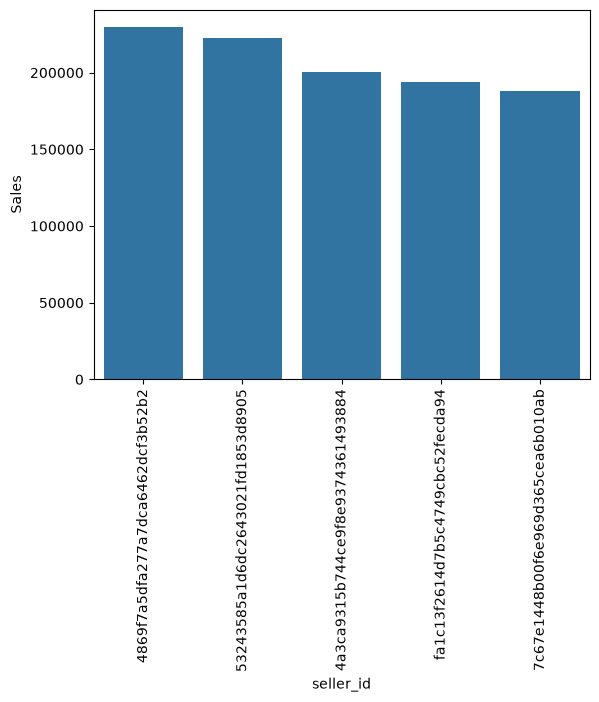

In [21]:

sns.barplot(x = "seller_id", y = "Sales", data = df.head(5))
plt.xticks(rotation = 90)
plt.show()

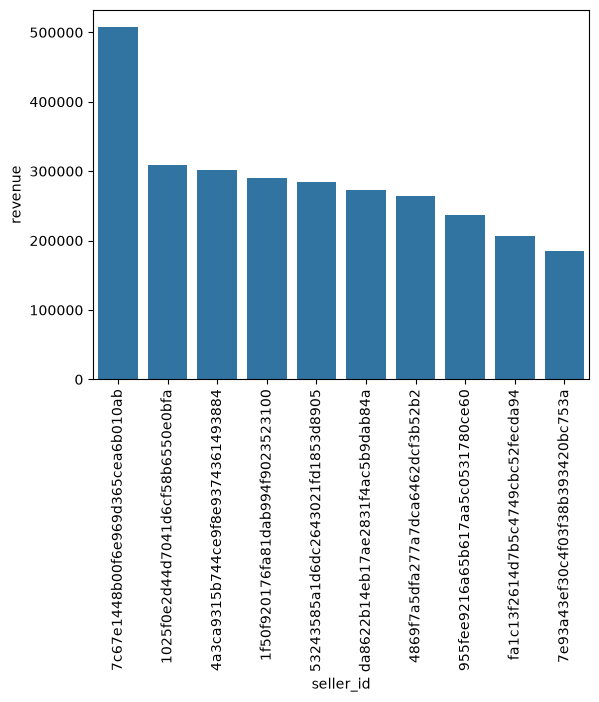

In [22]:
# 5. Calculate the total revenue generated by each seller, and rank them by revenue.

query = """
select *, dense_rank() over(order by revenue desc) as rn from
(select oi.seller_id,
sum(p.payment_value) as revenue
from order_items oi
join payments p on oi.order_id = p.order_id
group by oi.seller_id) as a
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns =  ["seller_id" , "revenue" , "rn"])
df.head(10)
sns.barplot(x = "seller_id", y = "revenue", data = df.head(10))
plt.xticks(rotation = 90)
plt.show()

In [23]:
# 1. Calculate the moving average of order values for each customer over their order history.
query = """select customer_id, 
order_purchase_timestamp, 
payment, round(avg(payment) 
over(partition by customer_id order by order_purchase_timestamp 
rows between 2 preceding and current row), 2) as mov_avg from 
(select orders.customer_id,
orders.order_purchase_timestamp, 
payments.payment_value as payment  
from orders join payments on orders.order_id = payments.order_id) as a"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_id", "order_purchase_timestamp", "payment", "mov_avg"])
df.head(20)

,customer_id,order_purchase_timestamp,payment,mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.74
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.41
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.42
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.35
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.01
5,0004164d20a9e969af783496f3408652,2017-04-12 08:35:12,71.80,71.80
6,000419c5494106c306a97b5635748086,2018-03-02 17:47:40,49.40,49.40
7,00046a560d407e99b969756e0b10f282,2017-12-18 11:08:30,166.59,166.59
8,00050bf6e01e69d5c0fd612f1bcfb69c,2017-09-17 16:04:44,85.23,85.23
9,000598caf2ef4117407665ac33275130,2018-08-11 12:14:35,1255.71,1255.71


In [24]:
# Calculate the cumulative sales per month for each year.

query = """select years, months, payment, sum(payment)
over (partition by years order by years, months) cumulative_sales from 
(select 
year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value), 2) as payment from orders join payments on orders.order_id = payments.order_id
group by years, months order by years, months) as a 
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Year", "Month", "Sales", "Cumulative_sales"])
df

,Year,Month,Sales,Cumulative_sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,138488.04
4,2017,2,291908.01,430396.05
5,2017,3,449863.60,880259.65
6,2017,4,417788.03,1298047.68
7,2017,5,592918.82,1890966.50
8,2017,6,511276.38,2402242.88
9,2017,7,592382.92,2994625.80


In [25]:
# 3. Calculate the year-over-year growth rate of total sales.


query = """
with my_temp as (select year(orders.order_purchase_timestamp) as years, 
round(sum(payments.payment_value), 2) 
as payment from orders join payments on 
orders.order_id = payments.order_id 
group by years order by years)

select years, 
round((payment- lag(payment, 1) over(order by years))/lag(payment, 1) over(order by years)*100, 2) 
as increment from my_temp;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Years", "YOY % Growth" ])
df

,Years,YOY % Growth
0,2016,NaN
1,2017,12112.7
2,2018,20.0


In [26]:
#  4. Calculate the retention rate of customers, defined as the percentage 
# of customers who make another purchase within 6 months of their first purchase.


query = """with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > a.first_order
and orders.order_purchase_timestamp < date_add(first_order,interval 6 month)
group by a.customer_id)

select 100*(count(distinct b.customer_id)/count(distinct a.customer_id)) from a
left join b on a.customer_id = b.customer_id;"""

cur.execute(query)
data = cur.fetchall()
data

[(Decimal('0.0000'),)]

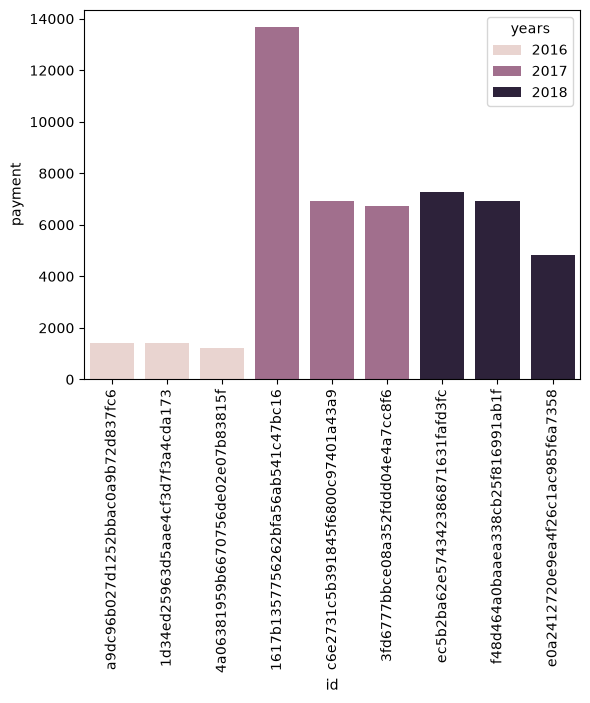

In [27]:
# Identify the top 3 customers who spent the most money in each year.

query = """select years, customer_id, round(payment, 2), d_rank from
(select 
orders.customer_id,
year(orders.order_purchase_timestamp) years,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp) 
order by sum(payments.payment_value) desc) d_rank
from orders join payments on orders.order_id = payments.order_id
group by year(orders.order_purchase_timestamp), orders.customer_id) 
as a where d_rank <= 3;
"""


cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "id", "payment", "Rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()

